In [16]:
# These are your top downregulated genes from the breast cancer project
# We'll map them from Affymetrix probe IDs to actual protein names

from Bio import Entrez, SeqIO
import pandas as pd
import requests

# Always tell NCBI who you are when using their database
Entrez.email = "kenny1autech1@gmail.com"

# Your top downregulated probe IDs from the last project
top_probes = ["237351_at", "214505_s_at", "89977_at", "214582_at", "223764_x_at"]

# The gene symbols we already identified
gene_symbols = ["FHL1", "PDE3B", "ACSM5", "VGLL3", "unknown"]

print("Target genes for protein structure analysis:")
for probe, gene in zip(top_probes, gene_symbols):
    print(f"  {probe} → {gene}")

Target genes for protein structure analysis:
  237351_at → FHL1
  214505_s_at → PDE3B
  89977_at → ACSM5
  214582_at → VGLL3
  223764_x_at → unknown


In [17]:
url = "https://rest.uniprot.org/uniprotkb/search?query=gene:FHL1+AND+organism_id:9606&format=json&size=1"

response = requests.get(url)
print(response.status_code)  # should be 200
data = response.json()       # converts the response to a Python dictionary
print(data)                  # print everything that came back

200
{'results': [{'entryType': 'UniProtKB unreviewed (TrEMBL)', 'primaryAccession': 'A0A0D9SGC5', 'uniProtkbId': 'A0A0D9SGC5_HUMAN', 'entryAudit': {'firstPublicDate': '2015-05-27', 'lastAnnotationUpdateDate': '2026-06-10', 'lastSequenceUpdateDate': '2015-05-27', 'entryVersion': 47, 'sequenceVersion': 1}, 'annotationScore': 1.0, 'organism': {'scientificName': 'Homo sapiens', 'commonName': 'Human', 'taxonId': 9606, 'evidences': [{'evidenceCode': 'ECO:0000313', 'source': 'Ensembl', 'id': 'ENSP00000487360.1'}, {'evidenceCode': 'ECO:0000313', 'source': 'Proteomes', 'id': 'UP000005640'}], 'lineage': ['Eukaryota', 'Metazoa', 'Chordata', 'Craniata', 'Vertebrata', 'Euteleostomi', 'Mammalia', 'Eutheria', 'Euarchontoglires', 'Primates', 'Haplorrhini', 'Catarrhini', 'Hominidae', 'Homo']}, 'proteinExistence': '1: Evidence at protein level', 'proteinDescription': {'submissionNames': [{'fullName': {'evidences': [{'evidenceCode': 'ECO:0000313', 'source': 'Ensembl', 'id': 'ENSP00000487360.1'}], 'value'

In [18]:
print(data["results"][0]["primaryAccession"])

A0A0D9SGC5


In [19]:
for gene in ["FHL1", "PDE3B", "ACSM5", "VGLL3"]:
    url = f"https://rest.uniprot.org/uniprotkb/search?query=gene:{gene}+AND+organism_id:9606&format=json&size=1"
    response = requests.get(url)
    accession = response.json()["results"][0]["primaryAccession"]
    print(f"{gene} -> {accession}")

FHL1 -> A0A0D9SGC5
PDE3B -> A0ACI8RBW0
ACSM5 -> A0A087WTR4
VGLL3 -> H7C571


In [20]:
UniProt_accessions = ["A0A0D9SGC5", "A0ACI8RBW0", "A0A087WTR4", "H7C571"]
for accession in UniProt_accessions:
    url = f"https://alphafold.ebi.ac.uk/files/AF-{accession}-F1-model_v4.pdb"
    response = requests.get(url)
    #write the downloaded alphafold structure into the file of my computer
    #pdb means protein data bank
    #wb means write file in binary format
    with open(f"{accession}.pdb", "wb") as file:
        #write the downloaded bytes into file
        file.write(response.content)

In [21]:
import os
os.listdir(".")

['.ipynb_checkpoints',
 '01_protein_identification.ipynb',
 'A0A087WTR4.pdb',
 'A0A0D9SGC5.pdb',
 'A0ACI8RBW0.pdb',
 'H7C571.pdb']

In [22]:
import shutil
import os

# Move each pdb file to the data folder
for accession in UniProt_accessions:
    shutil.move(f"{accession}.pdb", f"../data/{accession}.pdb")

print("Files moved to data folder")
os.listdir("../data")

Files moved to data folder


['.ipynb_checkpoints',
 'A0A087WTR4.pdb',
 'A0A0D9SGC5.pdb',
 'A0ACI8RBW0.pdb',
 'ACSM5.pdb',
 'FHL1.pdb',
 'H7C571.pdb',
 'PDE3B.pdb',
 'VGLL3.pdb']

In [23]:
# Get the full API response for FHL1
api_response = requests.get("https://alphafold.ebi.ac.uk/api/prediction/Q13642")
data = api_response.json()

# Print all the keys available
print(data[0].keys())

dict_keys(['toolUsed', 'providerId', 'entityType', 'isUniProt', 'modelEntityId', 'modelCreatedDate', 'sequenceVersionDate', 'globalMetricValue', 'fractionPlddtVeryLow', 'fractionPlddtLow', 'fractionPlddtConfident', 'fractionPlddtVeryHigh', 'latestVersion', 'allVersions', 'sequence', 'sequenceStart', 'sequenceEnd', 'sequenceChecksum', 'isUniProtReviewed', 'gene', 'uniprotAccession', 'uniprotId', 'uniprotDescription', 'taxId', 'organismScientificName', 'isUniProtReferenceProteome', 'chainId', 'bcifUrl', 'cifUrl', 'pdbUrl', 'paeImageUrl', 'msaUrl', 'plddtDocUrl', 'paeDocUrl', 'amAnnotationsUrl', 'amAnnotationsHg19Url', 'amAnnotationsHg38Url', 'isComplex', 'entryId', 'uniprotSequence', 'uniprotStart', 'uniprotEnd', 'isReferenceProteome', 'isReviewed'])


In [24]:
print(data[0]["pdbUrl"])

https://alphafold.ebi.ac.uk/files/AF-Q13642-F1-model_v6.pdb


In [25]:
gene_to_uniprot = {
    "FHL1": "Q13642",
    "PDE3B": "Q13370",
    "ACSM5": "Q6ZUV0",
    "VGLL3": "Q9Y468"
}

for gene, accession in gene_to_uniprot.items():
    # Get correct URL from API
    api = requests.get(f"https://alphafold.ebi.ac.uk/api/prediction/{accession}")
    pdb_url = api.json()[0]["pdbUrl"]
    
    # Download and save
    response = requests.get(pdb_url)
    with open(f"../data/{gene}.pdb", "wb") as f:
        f.write(response.content)
    print(f"{gene} - {len(response.content)} bytes")

FHL1 - 211085 bytes
PDE3B - 719522 bytes
ACSM5 - 165077 bytes
VGLL3 - 535733 bytes


In [26]:
#import the 3D viewer
import py3Dmol

#read the FHL1 structure file
with open("../data/FHL1.pdb", "r") as f:
    pdb_data = f.read()

#create a 3D viewer 
view = py3Dmol.view(width =800, height = 500)
#load the protein model, tells the viewer here are atoms. there are PDB format. Build the molecule."
view.addModel(pdb_data, "pdb")

#choose a visual style
view.setStyle({"cartoon": {"color": "spectrum"}})
#frames the protein and display
view.zoomTo()
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [27]:
#green region
#flat arrow- like ribbons (you can see them in a green region) called beta sheets. 
#these are where protein chains fold back on itself in a flat zigzag. They are rigid and structural

#alpha helices, coiled spiral shapes
#chain winds into a spring shape 
#structural and rigid

#whats interesting about FHL1 specifically:
#it has several distinct clustered regions separated by loops - those clusters are called LIM domains
#FHL1 stands for "Four and a half LIM domains" - 

#biologically the long extended shape acts like a scaffold protein, connecting different parts of the cell's machinery
#together. Cancer cells lose it because without the scaffold cells can grow and move more freely
#cancer cells benefit from losing it 



In [28]:
#import the 3D viewer
import py3Dmol

#list the 4 proteins i downloaded
accessions = ["FHL1", "PDE3B", "ACSM5", "VGLL3"]

#loop through each protein 
for accession in accessions:
    #read the FHL1 structure file
    with open(f"../data/{accession}.pdb", "r") as f:
        pdb_data = f.read()

    #create a 3D viewer 
    view = py3Dmol.view(width =800, height = 400)
    #load the protein model, tells the viewer here are atoms. there are PDB format. Build the molecule."
    view.addModel(pdb_data, "pdb")

    #choose a visual style
    view.setStyle({"cartoon": {"color": "spectrum"}})
    #frames the protein and display
    view.zoomTo()
    view.show

    #label each protein
    print(f"Displayed structure for: {accession}")
    view.show()
    
        

Displayed structure for: FHL1


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Displayed structure for: PDE3B


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Displayed structure for: ACSM5


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Displayed structure for: VGLL3


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [29]:
# Re-open FHL1 specifically for this analysis
with open("../data/FHL1.pdb", "r") as file:
    lines = file.readlines()

atom_count = sum(1 for line in lines if line.startswith("ATOM"))

# Get unique residue numbers = amino acid count
residues = set()
for line in lines:
    if line.startswith("ATOM"):
        residue_num = line[22:26].strip()
        residues.add(residue_num)

print(f"FHL1 amino acid count: {len(residues)}")
print(f"Atom count: {atom_count}")
print(f"Atoms per amino acid: {atom_count / len(residues):.1f}")

FHL1 amino acid count: 323
Atom count: 2532
Atoms per amino acid: 7.8


In [30]:
#create an empty list that will hold one dictionary per protein.
#each dictionary is one row of the final comparison table
results = []

#loop through each gene name in gene_to_uniprot mapping.
#this ensures the analysis runs for FHL1, PDE3B, ACSM5, VGLL3
for gene in gene_to_uniprot:
    
    #step 1. open the pdb file for this gene. 
    #this loads the actual 3D structure text
    with open(f"../data/{gene}.pdb", "r") as f:
        lines = f.readlines()
    
    #step 2: prepare counters for structural information.
    #atom_count = how many atoms the protein has (proxy for physical size)
    atom_count = 0
    residues = set()
    
    #go through pdb file line by line,
    #each line describes either an atom, a helix, a sheet, metadata etc
    for line in lines:
        #if the line starts with "ATOM", it contains a real atom coordinate
        #counting these tells you how big the protein is in 3D space
        if line.startswith("ATOM"):
            atom_count += 1
            #extract the residue number from column 22-26,
            #because in the pdb format, the residue number is stored in that exact column range
            #tells me which amino acid the atom belongs to
            #adding to a set ensures duplicates are removed
            #the final size of the set = number of amino acids
            residue_num = line[22:26].strip()
            residues.add(residue_num)
    
    #step 3 store the structural information for this protein
    #the dictionary becomes one row in my final table
    results.append({
        "gene": gene,           #which protein this row refers to
        "amino_acids": len(residues),  #chain length
        "atoms": atom_count     #total atom count, proxy for size
    })

#step 4 convert list of dictionaries into a clean table.
df = pd.DataFrame(results)
print(df)

    gene  amino_acids  atoms
0   FHL1          323   2532
1  PDE3B         1112   8748
2  ACSM5          252   1968
3  VGLL3          840   6500


In [31]:
# Biological roles of each protein
# This connects the structural data back to cancer biology

protein_info = {
    "FHL1": {
        "full_name": "Four and a Half LIM Domain Protein 1",
        "function": "Scaffold protein — holds the cell's structural machinery together",
        "cancer_role": "Tumour suppressor — lost in breast cancer, allowing cells to grow and migrate freely",
        "size_explains": "323 aa — small because it works as a connector, not an enzyme"
    },
    "PDE3B": {
        "full_name": "Phosphodiesterase 3B",
        "function": "Enzyme that breaks down cAMP — controls fat metabolism and insulin signalling",
        "cancer_role": "Loss disrupts metabolic signalling, helping cancer cells reprogram their energy use",
        "size_explains": "1112 aa — large because enzymes need complex active sites and regulatory regions"
    },
    "ACSM5": {
        "full_name": "Acyl-CoA Synthetase Medium Chain Family Member 5",
        "function": "Enzyme that activates fatty acids for metabolism",
        "cancer_role": "Loss disrupts fatty acid processing — cancer cells rewire fat metabolism to fuel rapid growth",
        "size_explains": "252 aa — smallest protein, does one specific job hence compact structure"
    },
    "VGLL3": {
        "full_name": "Vestigial Like Family Member 3",
        "function": "Transcription regulator — controls which genes get switched on or off",
        "cancer_role": "Directly linked to breast cancer — losing it dysregulates gene expression programs",
        "size_explains": "840 aa — large because transcription regulators need multiple binding domains"
    }
}

for gene, info in protein_info.items():
    print(f"\n{'='*50}")
    print(f"{gene} — {info['full_name']}")
    print(f"Function: {info['function']}")
    print(f"In cancer: {info['cancer_role']}")
    print(f"Size: {info['size_explains']}")


FHL1 — Four and a Half LIM Domain Protein 1
Function: Scaffold protein — holds the cell's structural machinery together
In cancer: Tumour suppressor — lost in breast cancer, allowing cells to grow and migrate freely
Size: 323 aa — small because it works as a connector, not an enzyme

PDE3B — Phosphodiesterase 3B
Function: Enzyme that breaks down cAMP — controls fat metabolism and insulin signalling
In cancer: Loss disrupts metabolic signalling, helping cancer cells reprogram their energy use
Size: 1112 aa — large because enzymes need complex active sites and regulatory regions

ACSM5 — Acyl-CoA Synthetase Medium Chain Family Member 5
Function: Enzyme that activates fatty acids for metabolism
In cancer: Loss disrupts fatty acid processing — cancer cells rewire fat metabolism to fuel rapid growth
Size: 252 aa — smallest protein, does one specific job hence compact structure

VGLL3 — Vestigial Like Family Member 3
Function: Transcription regulator — controls which genes get switched on o

In [32]:
# Goal: extract pLDDT confidence scores for FHL1
# Step 1: open the pdb file and read all lines
with open("../data/FHL1.pdb", "r") as file:
    lines = file.readlines()

# Step 2: loop through each line, extract pLDDT from B-factor column
plddt_scores = []
for line in lines:
    if line.startswith("ATOM"):
        # pLDDT score is stored in columns 60-66 (B-factor field)
        plddt = float(line[60:66].strip())
        plddt_scores.append(plddt)
    
#step 3 :compute summary statistics
import numpy as np
#average pLDDT
print(f"FHL1 average pLDDT: {np.mean(plddt_scores):.1f}")
#% above 90
print(f"% highly confident (>90): {sum(s > 90 for s in plddt_scores)/len(plddt_scores)*100:.1f}%")
#%below 50
print(f"% disordered (<50): {sum(s < 50 for s in plddt_scores)/len(plddt_scores)*100:.1f}%")

#distribution



FHL1 average pLDDT: 73.1
% highly confident (>90): 40.4%
% disordered (<50): 26.4%


In [37]:
import os
print(os.path.abspath("../data/"))

C:\Users\kenny\Documents\protein-structure-cancer-analysis\data


In [67]:
import numpy as np

#NOTE: FHL4 (Q8CDC8) is Mus musculus (mouse), not human.
#Human FHL4 is not available in AlphaFold.
#Mouse FHL4 is ~85% identical to human at sequence level.
#This limitation should be noted in any writeup.
filename_map = {
    "FHL1": "FHL1",
    "FHL2": "Q14192",
    "FHL3": "Q13643",
    "FHL4": "Q8CDC8",  # mouse — Mus musculus
}
results = {}

for gene, filename in filename_map.items():
    with open(f"../data/{filename}.pdb", "r") as file:
        lines = file.readlines()
    
    plddt_scores = []
    for line in lines:
        if line.startswith("ATOM"):
            plddt = float(line[60:66].strip())
            plddt_scores.append(plddt)
    
    results[gene] = {
        "avg": np.mean(plddt_scores),
        "high_conf": sum(s > 90 for s in plddt_scores) / len(plddt_scores) * 100,
        "disordered": sum(s < 50 for s in plddt_scores) / len(plddt_scores) * 100,
    }

print(f"{'Gene':<8} {'Avg pLDDT':>12} {'>90% conf':>12} {'<50% disord':>12}")
print("-" * 46)
for gene, r in results.items():
    print(f"{gene:<8} {r['avg']:>12.1f} {r['high_conf']:>11.1f}% {r['disordered']:>11.1f}%")

Gene        Avg pLDDT    >90% conf  <50% disord
----------------------------------------------
FHL1             73.1        40.4%        26.4%
FHL2             92.3        81.5%         0.0%
FHL3             91.8        79.3%         0.4%
FHL4             92.2        81.3%         0.0%


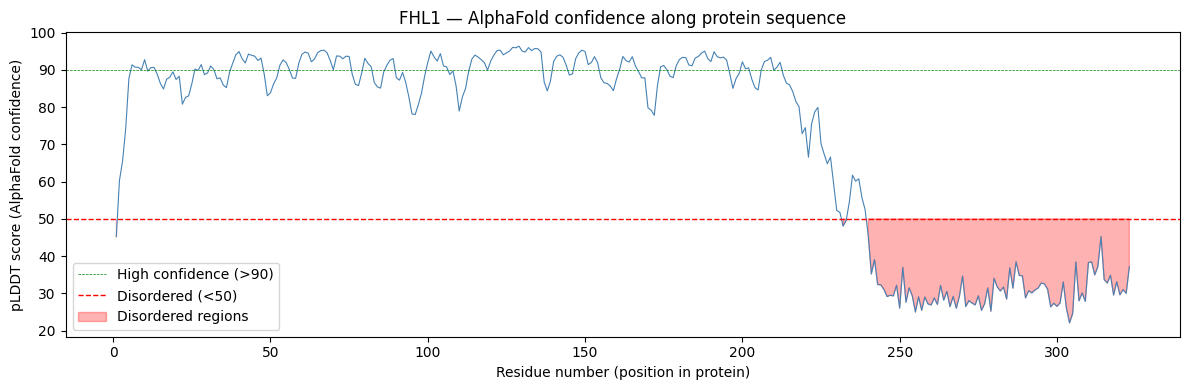

In [64]:
#GOAL: see how AlphaFold's confidence changes along FHL1's sequence, residue by residue

#WHY? Because confidence dips reveal DISORDERED regions. 
#Confidence peaks reveal structured domains.

#a residue is an amino acid in the protein chain
#each residue number = positions in the protein

#a CA atom is an alpha-carbon
#Every residue has exactly one CA atom.
#The CA is bonded to the residue's side chain (R-group).
#Counting CA atoms = counting residues.

#We want ONE pLDDT score per amino acid residue

residue_scores = {}

with open("../data/FHL1.pdb","r") as file:
    for line in file:
        if line.startswith("ATOM"):
            parts = line.split()
            atom_name = parts[2]
            if atom_name == "CA":
                residue_num = int(parts[5])
                plddt = float(parts[10])   # corrected index
                residue_scores[residue_num] = plddt

#goal: plot the plDDT score for each residue along FHL1's sequence
#WHY?: to see which regions are structured vs disordered instead of knowing the average
import matplotlib.pyplot as plt

#sort residues by position (dictionary order isn't guarenteed)
residues = sorted(residue_scores.keys())
scores = [residue_scores[r] for r in residues]
#-----------------------------------------------------------------
import numpy as np
#create a plot canvas
plt.figure(figsize=(12,4))
#x=residue number
#y = plDDT score
plt.plot(residues, scores, linewidth =0.8, color = "steelblue")
#>90 = AlphaFold is very confident = structured domain
plt.axhline(y=90, color="green", linestyle="--", linewidth=0.5, label="High confidence (>90)")
#<50 = AlphaFold is guessing = likely disordered
plt.axhline(y=50, color="red", linestyle="--", linewidth=1, label="Disordered (<50)")

plt.fill_between(residues, scores, 50,
                 where=[s < 50 for s in scores],
                 color="red", alpha=0.3, label="Disordered regions")
plt.xlabel("Residue number (position in protein)")
plt.ylabel("pLDDT score (AlphaFold confidence)")
plt.title("FHL1 — AlphaFold confidence along protein sequence")
plt.legend()
plt.tight_layout()

plt.savefig("../data/FHL1_plddt_plot.png", dpi=300)
plt.show()


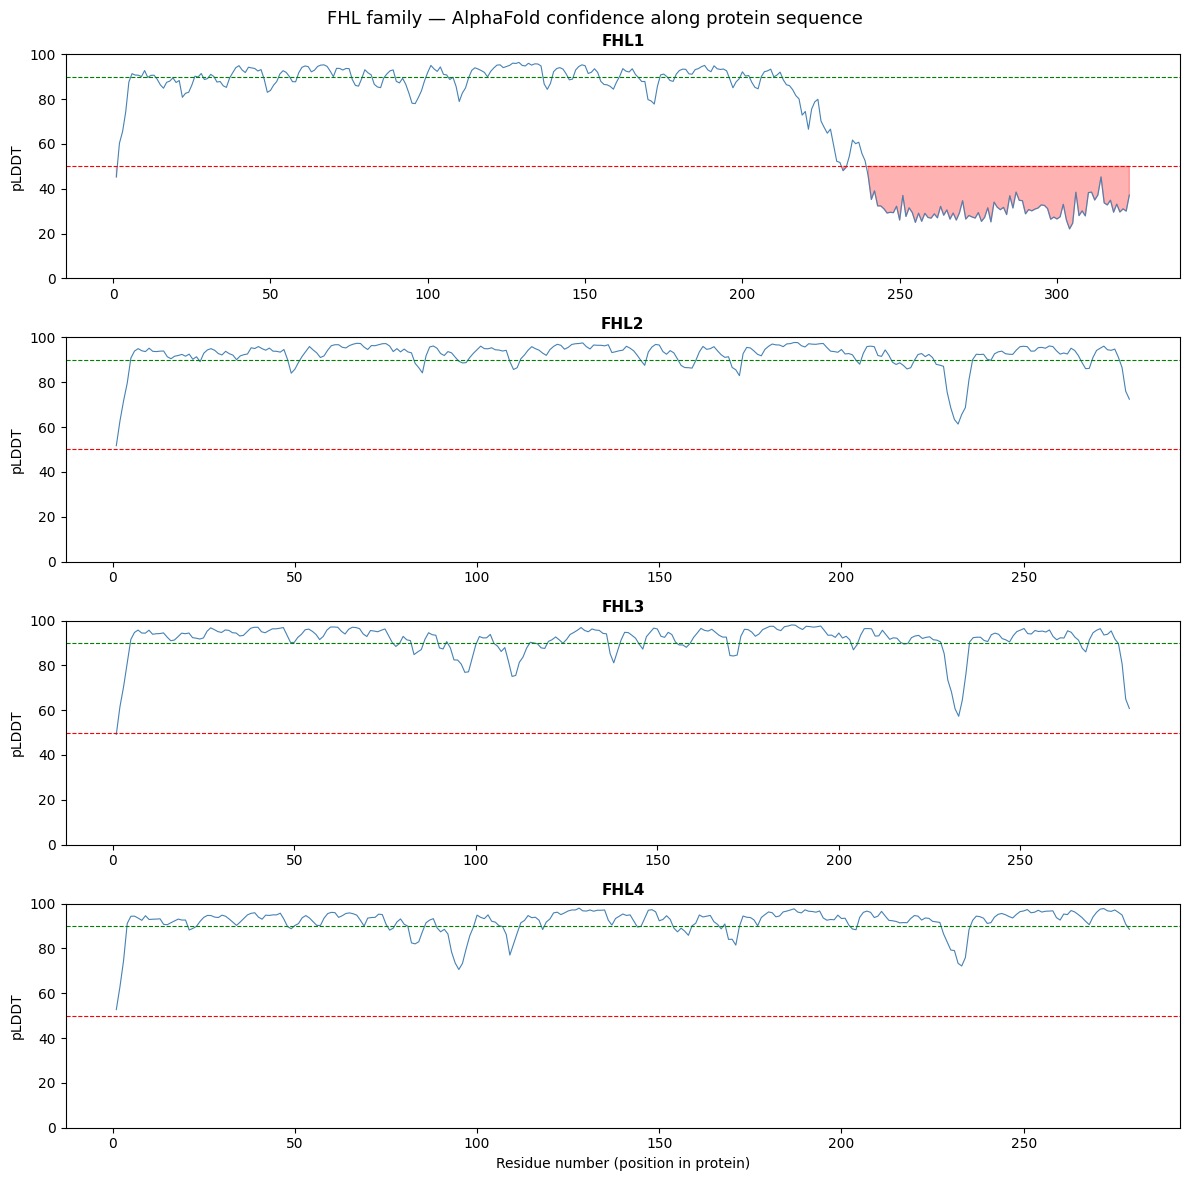


--- FHL1 ---
TITLE     ALPHAFOLD MONOMER V2.0 PREDICTION FOR FOUR AND A HALF LIM DOMAINS
TITLE    2 PROTEIN 1 (Q13642)
SOURCE    MOL_ID: 1;
SOURCE   2 ORGANISM_SCIENTIFIC: HOMO SAPIENS;
SOURCE   3 ORGANISM_TAXID: 9606

--- FHL2 ---
TITLE     ALPHAFOLD MONOMER V2.0 PREDICTION FOR FOUR AND A HALF LIM DOMAINS
TITLE    2 PROTEIN 2 (Q14192)
SOURCE    MOL_ID: 1;
SOURCE   2 ORGANISM_SCIENTIFIC: HOMO SAPIENS;
SOURCE   3 ORGANISM_TAXID: 9606

--- FHL3 ---
TITLE     ALPHAFOLD MONOMER V2.0 PREDICTION FOR FOUR AND A HALF LIM DOMAINS
TITLE    2 PROTEIN 3 (Q13643)
SOURCE    MOL_ID: 1;
SOURCE   2 ORGANISM_SCIENTIFIC: HOMO SAPIENS;
SOURCE   3 ORGANISM_TAXID: 9606

--- FHL4 ---
TITLE     ALPHAFOLD MONOMER V2.0 PREDICTION FOR FOUR AND A HALF LIM DOMAINS 4
TITLE    2 (Q8CDC8)
SOURCE    MOL_ID: 1;
SOURCE   2 ORGANISM_SCIENTIFIC: MUS MUSCULUS;
SOURCE   3 ORGANISM_TAXID: 10090


In [66]:
#GOAL: plot pLDDT confidence for all 4 FHL proteins side by side
#WHY? So we can directly compare where each protein is structured vs disordered
#and see visually why FHL1 is the outlier

import matplotlib.pyplot as plt

#map gene names to filenames (AlphaFold uses UniProt IDs)
filename_map = {
    "FHL1": "FHL1",
    "FHL2": "Q14192",
    "FHL3": "Q13643",
    "FHL4": "Q8CDC8",
}

#4 plots stacked vertically, one per protein
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=False)

for ax, (gene, filename) in zip(axes, filename_map.items()):
    
    #extract CA atom pLDDT scores for this protein
    residue_scores = {}
    with open(f"../data/{filename}.pdb", "r") as file:
        for line in file:
            if line.startswith("ATOM"):
                parts = line.split()
                if parts[2] == "CA":
                    residue_num = int(parts[5])
                    plddt = float(parts[10])
                    residue_scores[residue_num] = plddt

    residues = sorted(residue_scores.keys())
    scores = [residue_scores[r] for r in residues]

    #plot the confidence line
    ax.plot(residues, scores, linewidth=0.8, color="steelblue")

    #reference lines
    ax.axhline(y=90, color="green", linestyle="--", linewidth=0.8)
    ax.axhline(y=50, color="red", linestyle="--", linewidth=0.8)

    #shade disordered regions
    ax.fill_between(residues, scores, 50,
                    where=[s < 50 for s in scores],
                    color="red", alpha=0.3)

    ax.set_title(gene, fontsize=11, fontweight="bold")
    ax.set_ylabel("pLDDT")
    ax.set_ylim(0, 100)

axes[-1].set_xlabel("Residue number (position in protein)")
fig.suptitle("FHL family — AlphaFold confidence along protein sequence", fontsize=13)
plt.tight_layout()
plt.savefig("../data/FHL_comparison_plddt.png", dpi=300)
plt.show()
#GOAL: check the species of each protein
#WHY? If one is from mouse, we can't fairly compare it to the human ones
#PDB files store organism info in their header lines

for gene, filename in filename_map.items():
    print(f"\n--- {gene} ---")
    with open(f"../data/{filename}.pdb", "r") as file:
        for line in file:
            #ORGANISM and SOURCE lines in the header contain species info
            if any(keyword in line for keyword in ["ORGANISM", "SOURCE", "TITLE"]):
                print(line.strip())
            #stop reading once we hit the actual atom data
            if line.startswith("ATOM"):
                break

In [70]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        if file.endswith(".ipynb") or file.endswith(".png"):
            print(os.path.join(root, file))

..\data\FHL1_plddt_plot.png
..\data\FHL_comparison_plddt.png
..\notebooks\01_protein_identification.ipynb
..\notebooks\.ipynb_checkpoints\01_protein_identification-checkpoint.ipynb
